# United Kingdom — ESA revenue: series and statistical forecasts

A companion to [`chartbook.ipynb`](chartbook.ipynb). For each granular line it
keeps the chartbook's levels chart, adds the same series **as a share of GDP**
(call it *X*), and then puts four standard univariate forecasts of *X* out to
2031 beside each other, plus their combination.

| method | what it is |
|---|---|
| `auto.arima` | R `forecast::auto.arima`, via `pmdarima.auto_arima` — AICc over non-seasonal ARIMA |
| `ets` | R `forecast::ets`, via statsmodels `ETSModel` — AICc over the error/trend/damped grid |
| `prophet` | Facebook `prophet` — linear trend, no seasonality (annual data) |
| `uc` | statsmodels `UnobservedComponents` — local linear trend with a damped stochastic cycle |
| `combination` | the mean of the four, with within- plus between-model variance |

Every forecast is **fitted on outturn only** — the sample ends at the last
actual, never at the last official projection — so where a line carries an
official forecast the two appear on the same axes and can be read against each
other. The <span style="color:#2a78d6">blue dashed</span> line is the official
strict forecast; the <span style="color:#4a3aa7">violet</span> one and its fan
are the statistical model.

**These are a benchmark, not a rival forecast.** Nothing here enters the
canonical layer, the trees or the flat files. They exist so that an official
projection — or the absence of one — can be read against what the history
alone would have said.

Three things to keep in mind:

* **Short samples.** These are annual series with 30–61 observations. Six or
  seven years ahead is a long way on that, and the fans are wide for a reason.
* **`auto.arima` and `ets` often choose a random walk or simple exponential
  smoothing**, whose point forecast is a flat line at the last value. That is
  the honest answer from those methods on this data, not a failure.
* **Prophet's intervals are the narrowest here**, which on 30 annual points
  says more about Prophet's uncertainty model than about the series. Read the
  four together; that is what the combination is for.

Charts and numbers come from [`../deliverables/statistical_forecasts.csv`](../deliverables/statistical_forecasts.csv),
written by `ggfiscal statistical-forecasts`; this notebook only reads and
plots. Axes: the levels and %-of-GDP charts share the country axis used
throughout the chartbook (to 2031); the fan charts start at 2000 so the
forecast is legible.

In [1]:
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as Image_display, display
from PIL import Image
import io

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "statistical_forecasts.csv").exists())
DELIV = ROOT / "deliverables"
load = lambda n: pd.read_csv(DELIV / f"{n}.csv")

TREE = pd.concat([load("expenditure_cofog"), load("expenditure_esa"),
                  load("revenue_esa")], ignore_index=True)
FORECASTS = load("statistical_forecasts")
CATALOGUE = load("series_catalogue")
NAME = dict(zip(CATALOGUE.iso3, CATALOGUE.country))

# Palette: blue is the published strict series (solid outturn, dashed where
# an official forecast exists), orange the maximum extension, violet the
# statistical forecast. Validated all-pairs, and line style repeats every
# distinction so identity never rests on colour alone.
BLUE, ORANGE, VIOLET = "#2a78d6", "#eb6834", "#4a3aa7"
INK, MUTED, AXIS = "#0b0b0b", "#898781", "#c3c2b7"
SURFACE, SHADE = "#fcfcfb", "#eceae4"
XMAX, FAN_FROM = 2031, 2000
Z95, Z80 = 1.959964, 1.281552

plt.rcParams.update({
    "figure.figsize": (6.9, 2.7), "figure.dpi": 72,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK, "axes.titlecolor": INK, "axes.titlesize": 10.5,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5, "grid.color": AXIS, "grid.alpha": 0.45,
    "grid.linewidth": 0.6, "legend.frameon": False, "legend.fontsize": 8,
    "lines.linewidth": 2,
})

XLIM = {}
for _iso in TREE.iso3.unique():
    _lo = int(TREE.query("iso3 == @_iso").year.min())
    _pad = (XMAX - _lo) * 0.035
    XLIM[_iso] = (_lo - _pad, XMAX + _pad)


def _palette():
    """Fixed palette of exactly the colours used, so quantising cannot shift
    a hue that happens to occupy few pixels (a dashed line, a fan edge)."""
    from matplotlib.colors import to_rgb
    entries = [to_rgb(SURFACE), to_rgb(SHADE)]
    for mark in (INK, MUTED, AXIS, BLUE, ORANGE, VIOLET):
        m = to_rgb(mark)
        for ground in (SURFACE, SHADE):
            g = to_rgb(ground)
            entries += [tuple(m[i] + (g[i] - m[i]) * t for i in range(3))
                        for t in (0.0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.88)]
    flat = [round(255 * v) for e in entries for v in e]
    pal = Image.new("P", (1, 1))
    pal.putpalette(flat + [0] * (768 - len(flat)))
    return pal


PALETTE = _palette()


def show(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=plt.rcParams["figure.dpi"])
    plt.close(fig)
    small = Image.open(buf).convert("RGB").quantize(
        palette=PALETTE, dither=Image.Dither.NONE)
    out = io.BytesIO()
    small.save(out, format="PNG", optimize=True)
    display(Image_display(data=out.getvalue()))


def thousands(ax):
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


def _series(iso3, line_code, variant="strict", column="value_lcu_mn"):
    d = TREE.query("iso3 == @iso3 and line_code == @line_code and "
                   "variant == @variant").dropna(subset=[column])
    return d.set_index("year")[column].sort_index()


def _seams(g):
    g = g.sort_values("year")
    key = list(zip(g.observation_type, g.source_id.fillna("")))
    return [int(y) for (a, b), y in zip(zip(key, key[1:]), g.year[1:]) if a != b]


def levels(iso3, line_code):
    """Chart 1 — the chartbook's own levels chart, unchanged."""
    g = TREE.query("iso3 == @iso3 and line_code == @line_code")
    strict = g.query("variant == 'strict'").sort_values("year")
    mx = g.query("variant == 'maximum_extension'").sort_values("year")
    actual = g.query("basis == 'actual'").year.max()
    lo, hi = XLIM[iso3]

    fig, ax = plt.subplots()
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    window = lambda d: d[d.year <= hi + 1]
    if len(mx) > len(strict):
        ax.plot(window(mx).year, window(mx).value_lcu_mn, color=ORANGE,
                ls="--", label="maximum_extension")
    ax.plot(window(strict).year, window(strict).value_lcu_mn, color=BLUE,
            label="strict")
    for year in _seams(mx):
        ax.axvline(year, color=MUTED, ls=":", lw=0.9, alpha=0.8, zorder=1)
    ax.set_title(f"{NAME[iso3]} · {line_code} — {g.line_label.iloc[0]} (levels)")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    if len(mx) > len(strict):
        ax.legend(loc="upper left")
    fig.tight_layout()
    show(fig)


def share(iso3, line_code):
    """Chart 2 — X: the same strict series as a share of GDP."""
    g = TREE.query("iso3 == @iso3 and line_code == @line_code and "
                   "variant == 'strict'").dropna(subset=["pct_gdp"])
    actual = g.query("basis == 'actual'").year.max()
    lo, hi = XLIM[iso3]

    fig, ax = plt.subplots()
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    hist = g[g.basis == "actual"].sort_values("year")
    off = g[(g.basis == "forecast") & (g.year <= hi + 1)].sort_values("year")
    ax.plot(hist.year, hist.pct_gdp, color=BLUE, label="outturn")
    if len(off):
        ax.plot([actual, *off.year], [hist.pct_gdp.iloc[-1], *off.pct_gdp],
                color=BLUE, ls="--", label="official strict forecast")
    ax.set_title(f"{NAME[iso3]} · {line_code} — {g.line_label.iloc[0]} "
                 "(% of GDP)")
    ax.set_ylabel("% of GDP")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    if len(off):
        ax.legend(loc="upper left")
    fig.tight_layout()
    show(fig)
    span = f"{int(g.year.min())}-{int(actual)}"
    print(f"outturn {span}"
          + (f"; official strict forecast to {int(off.year.max())}"
             if len(off) else "; no official forecast"))


def fan(iso3, line_code, method):
    """Charts 3-7 — one method's forecast of X to 2031, with 80% and 95%
    bands from its own standard errors."""
    f = FORECASTS.query("iso3 == @iso3 and line_code == @line_code and "
                        "method == @method").sort_values("year")
    g = TREE.query("iso3 == @iso3 and line_code == @line_code and "
                   "variant == 'strict'").dropna(subset=["pct_gdp"])
    hist = g[(g.basis == "actual") & (g.year >= FAN_FROM)].sort_values("year")
    if f.empty:
        print(f"{iso3} {line_code}: no statistical forecast — the official "
              "strict series already reaches 2031 or beyond.")
        return
    anchor_year = int(f.year.min()) - 1
    anchor = float(g.query("year == @anchor_year").pct_gdp.iloc[0])

    fig, ax = plt.subplots()
    ax.set_xlim(FAN_FROM - 0.6, XMAX + 0.6)
    ax.axvspan(anchor_year, XMAX + 0.6, color=SHADE, zorder=0, lw=0)
    for z, alpha, lab in ((Z95, 0.13, "95%"), (Z80, 0.22, "80%")):
        ax.fill_between([anchor_year, *f.year],
                        [anchor, *(f.pct_gdp - z * f.se)],
                        [anchor, *(f.pct_gdp + z * f.se)],
                        color=VIOLET, alpha=alpha, lw=0, zorder=1,
                        label=f"{lab} interval")
    ax.plot(hist.year, hist.pct_gdp, color=BLUE, label="outturn", zorder=3)
    off = g[(g.basis == "forecast") & (g.year <= XMAX)].sort_values("year")
    if len(off):
        ax.plot([anchor_year, *off.year], [anchor, *off.pct_gdp], color=BLUE,
                ls="--", label="official strict forecast", zorder=3)
    ax.plot([anchor_year, *f.year], [anchor, *f.pct_gdp], color=VIOLET,
            ls="--", label=f"{method} forecast", zorder=4)
    ax.set_title(f"{NAME[iso3]} · {line_code} — {method}")
    ax.set_ylabel("% of GDP")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(5))
    ax.legend(loc="upper left", ncol=2)
    fig.tight_layout()
    show(fig)

    row = f.iloc[-1]
    print(fill(f"model: {row.model}; fitted on {int(row.fit_first_year)}-"
               f"{int(row.fit_last_year)} ({int(row.n_obs)} outturn "
               f"observations). {int(row.year)}: {row.pct_gdp:.2f}% of GDP, "
               f"95% interval {row.lo95:.2f} to {row.hi95:.2f}.", 104,
               subsequent_indent=" " * 7))


print(f"{len(TREE):,} tree rows, {len(FORECASTS):,} forecast rows covering "
      f"{FORECASTS.groupby(['iso3', 'line_code']).ngroups} series x "
      f"{FORECASTS.method.nunique()} methods to {int(FORECASTS.year.max())}.")

10,544 tree rows, 3,610 forecast rows covering 113 series x 5 methods to 2031.


## R01 — Value added tax

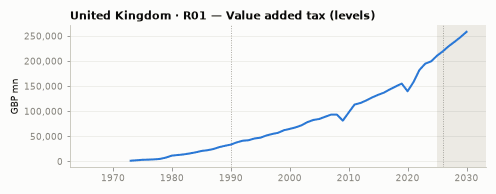

In [2]:
levels("GBR", "R01")

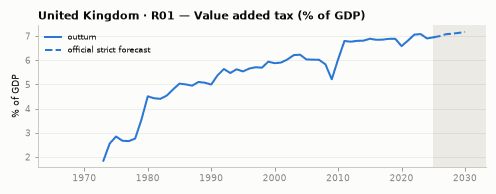

outturn 1973-2025; official strict forecast to 2030


In [3]:
share("GBR", "R01")

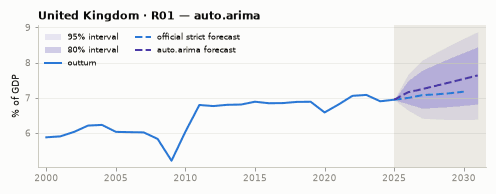

model: ARIMA(0, 1, 2)+drift; fitted on 1973-2025 (53 outturn observations). 2031: 7.63% of GDP, 95%
       interval 6.39 to 8.87.


In [4]:
fan("GBR", "R01", "auto.arima")

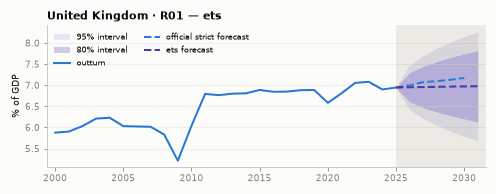

model: ETS(A,Ad,N); fitted on 1973-2025 (53 outturn observations). 2031: 6.98% of GDP, 95% interval 5.69
       to 8.26.


In [5]:
fan("GBR", "R01", "ets")

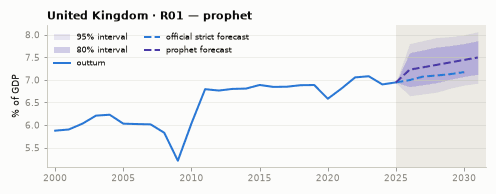

model: Prophet(linear trend); fitted on 1973-2025 (53 outturn observations). 2031: 7.50% of GDP, 95%
       interval 6.93 to 8.06.


In [6]:
fan("GBR", "R01", "prophet")

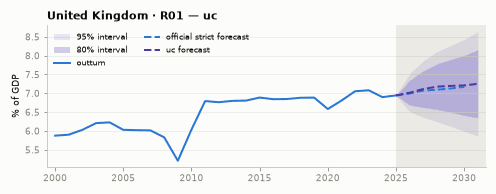

model: UC(local linear trend + damped cycle); fitted on 1973-2025 (53 outturn observations). 2031: 7.25%
       of GDP, 95% interval 5.87 to 8.63.


In [7]:
fan("GBR", "R01", "uc")

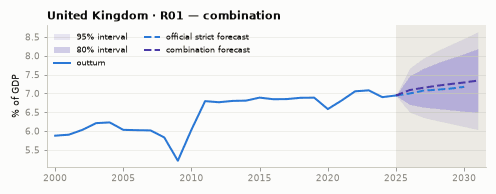

model: mean of 4 + between-model variance; fitted on 1973-2025 (53 outturn observations). 2031: 7.34% of
       GDP, 95% interval 6.04 to 8.63.


In [8]:
fan("GBR", "R01", "combination")

## R02 — Other taxes on production and imports

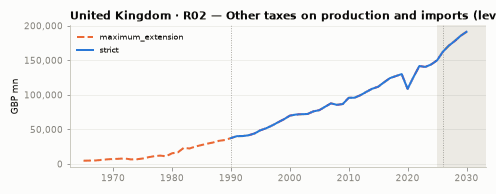

In [9]:
levels("GBR", "R02")

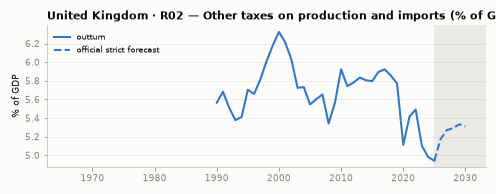

outturn 1990-2025; official strict forecast to 2030


In [10]:
share("GBR", "R02")

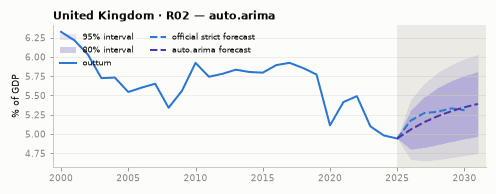

model: ARIMA(1, 0, 0)+drift; fitted on 1990-2025 (36 outturn observations). 2031: 5.39% of GDP, 95%
       interval 4.75 to 6.03.


In [11]:
fan("GBR", "R02", "auto.arima")

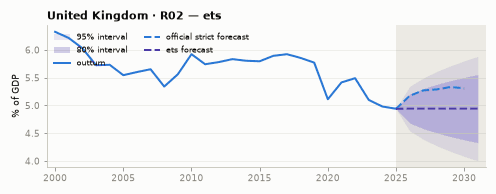

model: ETS(A,N,N); fitted on 1990-2025 (36 outturn observations). 2031: 4.94% of GDP, 95% interval 4.01
       to 5.88.


In [12]:
fan("GBR", "R02", "ets")

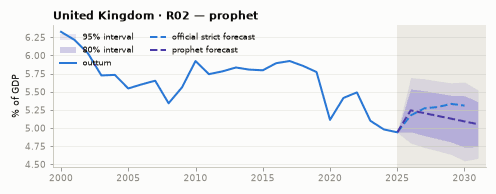

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: 5.05% of GDP, 95%
       interval 4.58 to 5.52.


In [13]:
fan("GBR", "R02", "prophet")

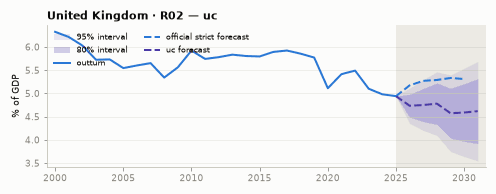

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031: 4.62%
       of GDP, 95% interval 3.55 to 5.69.


In [14]:
fan("GBR", "R02", "uc")

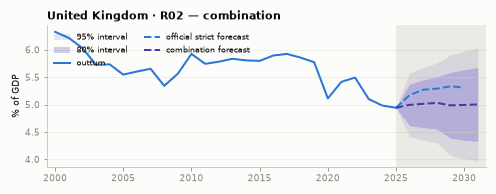

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: 5.00% of
       GDP, 95% interval 3.98 to 6.03.


In [15]:
fan("GBR", "R02", "combination")

## R02_A — Excise duties

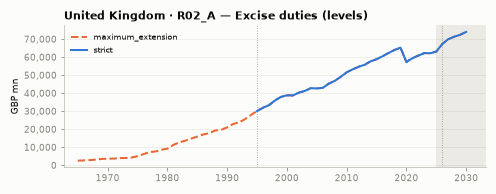

In [16]:
levels("GBR", "R02_A")

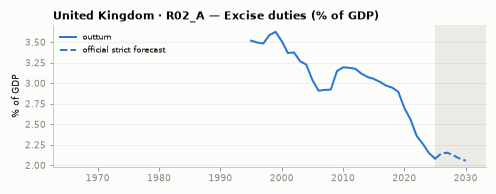

outturn 1995-2025; official strict forecast to 2030


In [17]:
share("GBR", "R02_A")

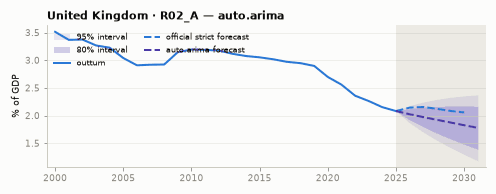

model: ARIMA(1, 1, 0)+drift; fitted on 1995-2025 (31 outturn observations). 2031: 1.78% of GDP, 95%
       interval 1.18 to 2.37.


In [18]:
fan("GBR", "R02_A", "auto.arima")

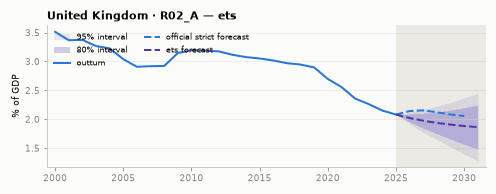

model: ETS(M,Ad,N); fitted on 1995-2025 (31 outturn observations). 2031: 1.86% of GDP, 95% interval 1.28
       to 2.45.


In [19]:
fan("GBR", "R02_A", "ets")

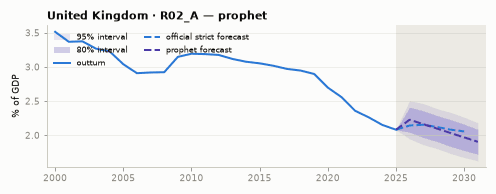

model: Prophet(linear trend); fitted on 1995-2025 (31 outturn observations). 2031: 1.90% of GDP, 95%
       interval 1.63 to 2.18.


In [20]:
fan("GBR", "R02_A", "prophet")

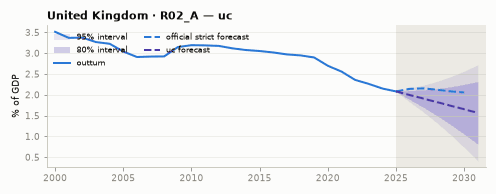

model: UC(local linear trend + damped cycle); fitted on 1995-2025 (31 outturn observations). 2031: 1.57%
       of GDP, 95% interval 0.42 to 2.72.


In [21]:
fan("GBR", "R02_A", "uc")

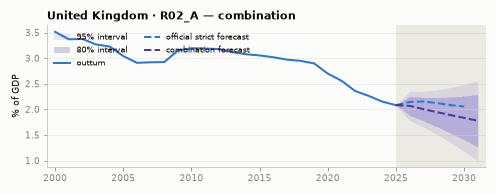

model: mean of 4 + between-model variance; fitted on 1995-2025 (31 outturn observations). 2031: 1.78% of
       GDP, 95% interval 1.00 to 2.56.


In [22]:
fan("GBR", "R02_A", "combination")

## R02_X — Other taxes on production and imports excluding excise duties

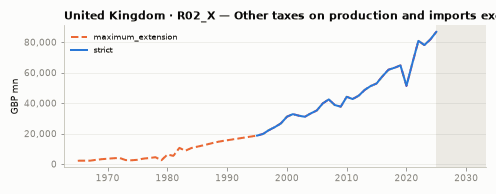

In [23]:
levels("GBR", "R02_X")

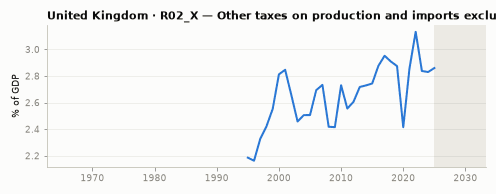

outturn 1995-2025; no official forecast


In [24]:
share("GBR", "R02_X")

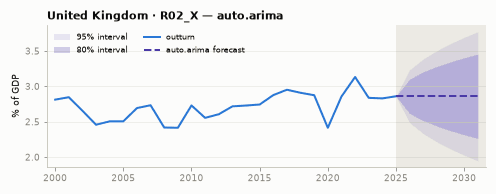

model: ARIMA(0, 1, 0); fitted on 1995-2025 (31 outturn observations). 2031: 2.86% of GDP, 95% interval
       1.95 to 3.77.


In [25]:
fan("GBR", "R02_X", "auto.arima")

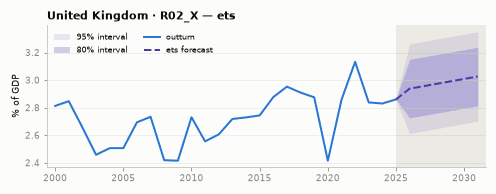

model: ETS(A,A,N); fitted on 1995-2025 (31 outturn observations). 2031: 3.03% of GDP, 95% interval 2.70
       to 3.35.


In [26]:
fan("GBR", "R02_X", "ets")

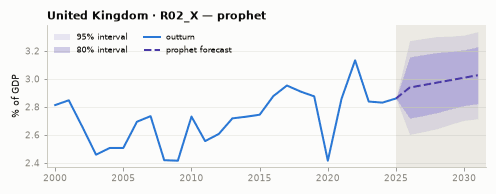

model: Prophet(linear trend); fitted on 1995-2025 (31 outturn observations). 2031: 3.03% of GDP, 95%
       interval 2.72 to 3.34.


In [27]:
fan("GBR", "R02_X", "prophet")

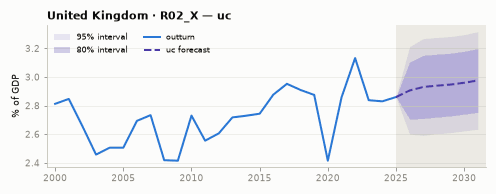

model: UC(local linear trend + damped cycle); fitted on 1995-2025 (31 outturn observations). 2031: 2.98%
       of GDP, 95% interval 2.64 to 3.32.


In [28]:
fan("GBR", "R02_X", "uc")

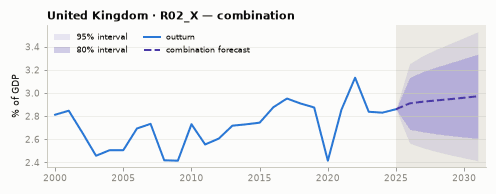

model: mean of 4 + between-model variance; fitted on 1995-2025 (31 outturn observations). 2031: 2.97% of
       GDP, 95% interval 2.42 to 3.53.


In [29]:
fan("GBR", "R02_X", "combination")

## R03 — Taxes on household income

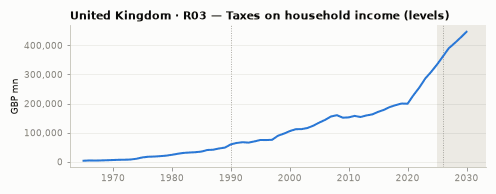

In [30]:
levels("GBR", "R03")

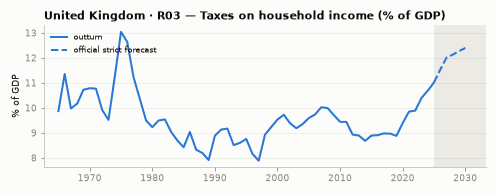

outturn 1965-2025; official strict forecast to 2030


In [31]:
share("GBR", "R03")

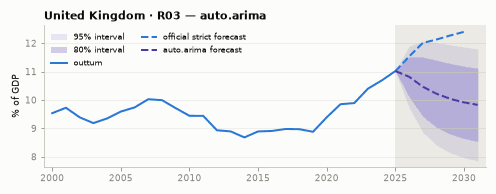

model: ARIMA(1, 0, 1)+drift; fitted on 1965-2025 (61 outturn observations). 2031: 9.83% of GDP, 95%
       interval 7.86 to 11.80.


In [32]:
fan("GBR", "R03", "auto.arima")

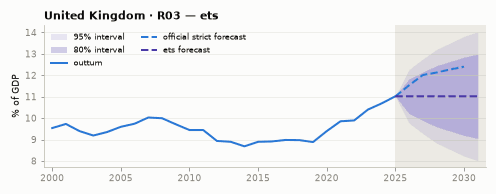

model: ETS(M,N,N); fitted on 1965-2025 (61 outturn observations). 2031: 11.02% of GDP, 95% interval 8.01
       to 14.03.


In [33]:
fan("GBR", "R03", "ets")

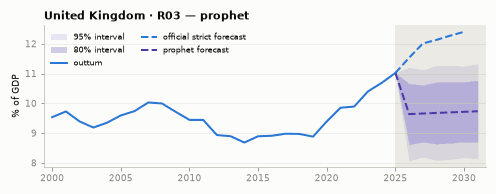

model: Prophet(linear trend); fitted on 1965-2025 (61 outturn observations). 2031: 9.73% of GDP, 95%
       interval 8.14 to 11.32.


In [34]:
fan("GBR", "R03", "prophet")

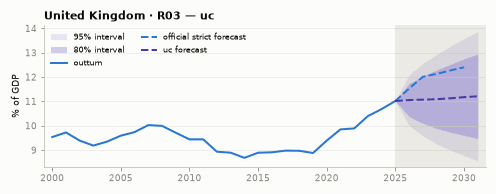

model: UC(local linear trend + damped cycle); fitted on 1965-2025 (61 outturn observations). 2031:
       11.21% of GDP, 95% interval 8.56 to 13.86.


In [35]:
fan("GBR", "R03", "uc")

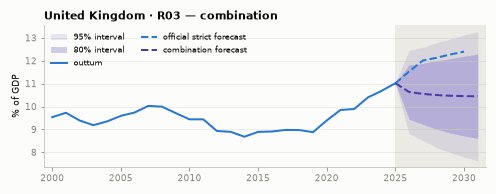

model: mean of 4 + between-model variance; fitted on 1965-2025 (61 outturn observations). 2031: 10.45%
       of GDP, 95% interval 7.63 to 13.26.


In [36]:
fan("GBR", "R03", "combination")

## R04 — Taxes on corporate income

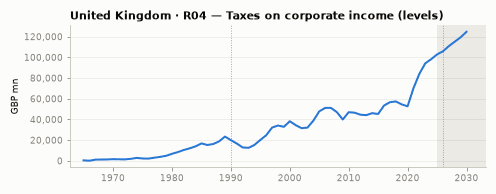

In [37]:
levels("GBR", "R04")

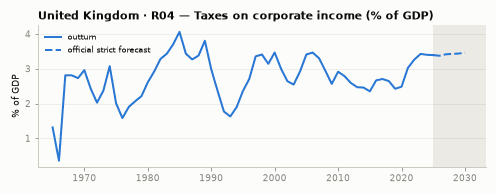

outturn 1965-2025; official strict forecast to 2030


In [38]:
share("GBR", "R04")

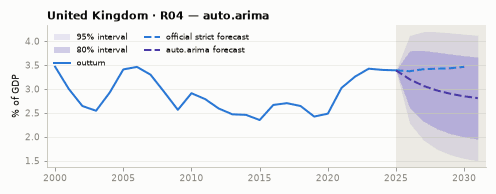

model: ARIMA(1, 0, 0)+drift; fitted on 1965-2025 (61 outturn observations). 2031: 2.81% of GDP, 95%
       interval 1.50 to 4.12.


In [39]:
fan("GBR", "R04", "auto.arima")

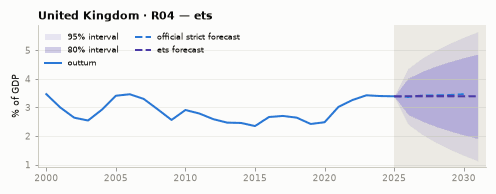

model: ETS(A,N,N); fitted on 1965-2025 (61 outturn observations). 2031: 3.39% of GDP, 95% interval 1.14
       to 5.64.


In [40]:
fan("GBR", "R04", "ets")

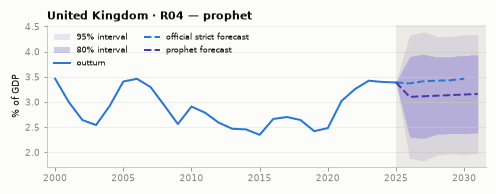

model: Prophet(linear trend); fitted on 1965-2025 (61 outturn observations). 2031: 3.16% of GDP, 95%
       interval 1.98 to 4.34.


In [41]:
fan("GBR", "R04", "prophet")

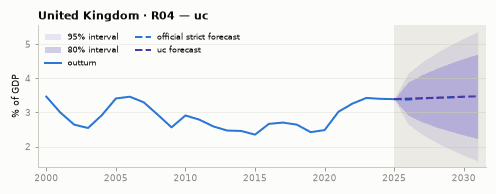

model: UC(local linear trend + damped cycle); fitted on 1965-2025 (61 outturn observations). 2031: 3.47%
       of GDP, 95% interval 1.59 to 5.36.


In [42]:
fan("GBR", "R04", "uc")

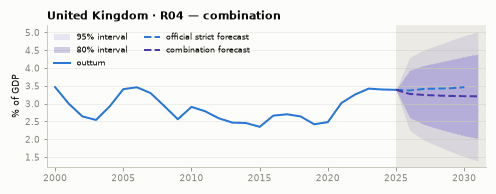

model: mean of 4 + between-model variance; fitted on 1965-2025 (61 outturn observations). 2031: 3.21% of
       GDP, 95% interval 1.40 to 5.02.


In [43]:
fan("GBR", "R04", "combination")

## R05 — Other current taxes and capital taxes

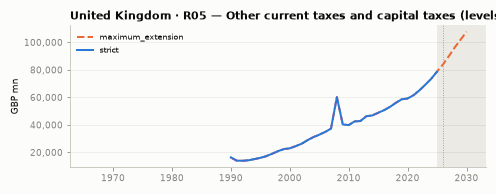

In [44]:
levels("GBR", "R05")

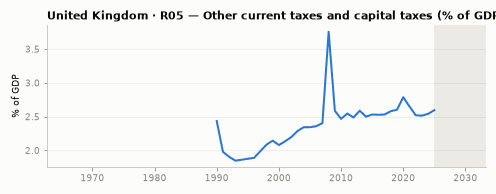

outturn 1990-2025; no official forecast


In [45]:
share("GBR", "R05")

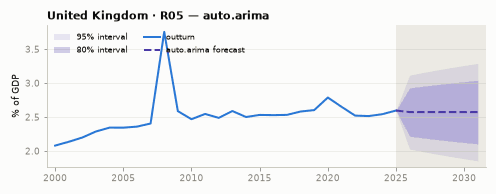

model: ARIMA(0, 1, 1); fitted on 1990-2025 (36 outturn observations). 2031: 2.57% of GDP, 95% interval
       1.86 to 3.29.


In [46]:
fan("GBR", "R05", "auto.arima")

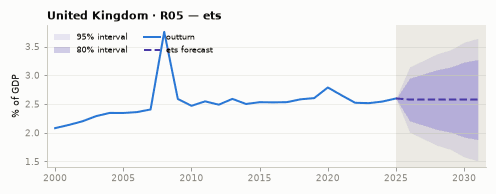

model: ETS(M,N,N); fitted on 1990-2025 (36 outturn observations). 2031: 2.58% of GDP, 95% interval 1.51
       to 3.64.


In [47]:
fan("GBR", "R05", "ets")

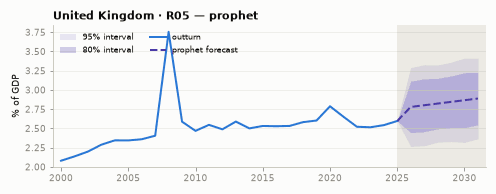

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: 2.89% of GDP, 95%
       interval 2.37 to 3.41.


In [48]:
fan("GBR", "R05", "prophet")

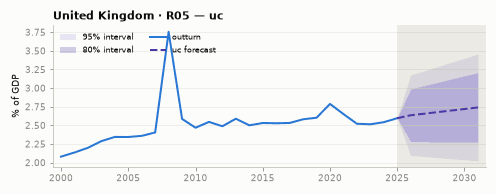

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031: 2.74%
       of GDP, 95% interval 2.03 to 3.46.


In [49]:
fan("GBR", "R05", "uc")

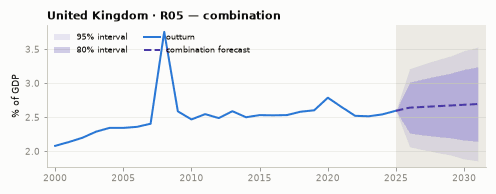

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: 2.69% of
       GDP, 95% interval 1.86 to 3.53.


In [50]:
fan("GBR", "R05", "combination")

## R06 — Net social contributions

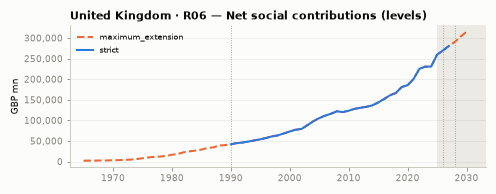

In [51]:
levels("GBR", "R06")

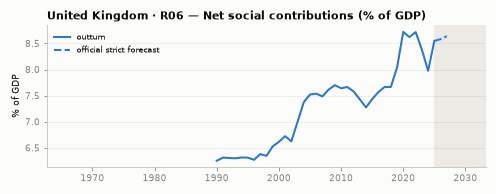

outturn 1990-2025; official strict forecast to 2027


In [52]:
share("GBR", "R06")

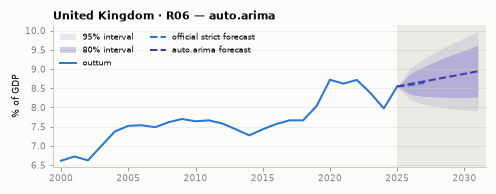

model: ARIMA(0, 1, 0)+drift; fitted on 1990-2025 (36 outturn observations). 2031: 8.94% of GDP, 95%
       interval 7.91 to 9.97.


In [53]:
fan("GBR", "R06", "auto.arima")

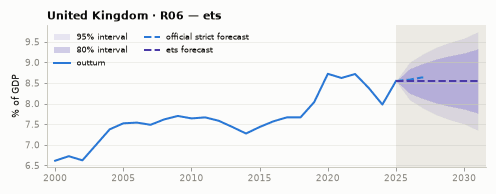

model: ETS(M,N,N); fitted on 1990-2025 (36 outturn observations). 2031: 8.55% of GDP, 95% interval 7.36
       to 9.74.


In [54]:
fan("GBR", "R06", "ets")

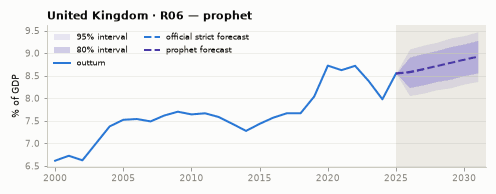

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: 8.92% of GDP, 95%
       interval 8.37 to 9.47.


In [55]:
fan("GBR", "R06", "prophet")

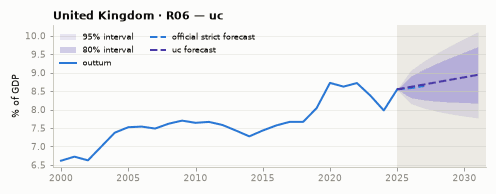

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031: 8.94%
       of GDP, 95% interval 7.78 to 10.10.


In [56]:
fan("GBR", "R06", "uc")

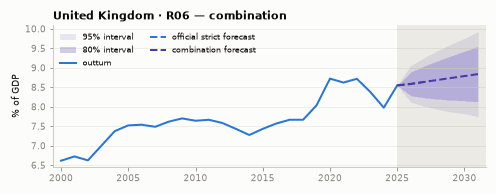

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: 8.84% of
       GDP, 95% interval 7.75 to 9.92.


In [57]:
fan("GBR", "R06", "combination")

## R06_E — Employers' actual social contributions

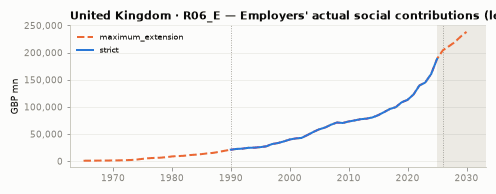

In [58]:
levels("GBR", "R06_E")

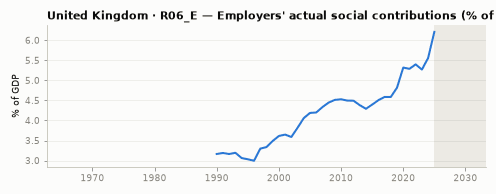

outturn 1990-2025; no official forecast


In [59]:
share("GBR", "R06_E")

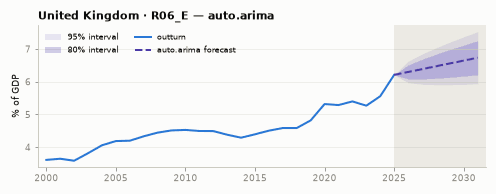

model: ARIMA(0, 1, 0)+drift; fitted on 1990-2025 (36 outturn observations). 2031: 6.73% of GDP, 95%
       interval 5.94 to 7.52.


In [60]:
fan("GBR", "R06_E", "auto.arima")

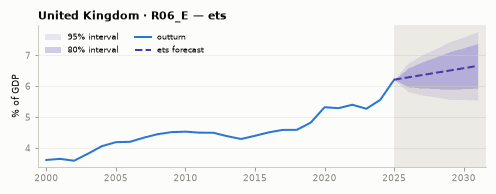

model: ETS(M,A,N); fitted on 1990-2025 (36 outturn observations). 2031: 6.66% of GDP, 95% interval 5.55
       to 7.76.


In [61]:
fan("GBR", "R06_E", "ets")

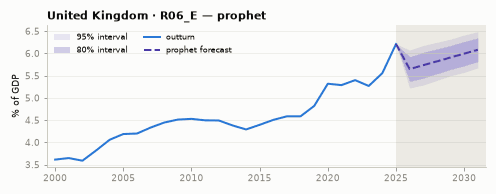

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: 6.08% of GDP, 95%
       interval 5.68 to 6.49.


In [62]:
fan("GBR", "R06_E", "prophet")

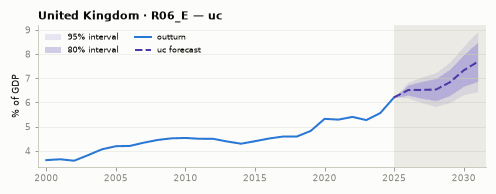

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031: 7.68%
       of GDP, 95% interval 6.44 to 8.92.


In [63]:
fan("GBR", "R06_E", "uc")

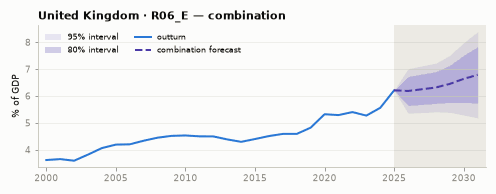

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: 6.79% of
       GDP, 95% interval 5.19 to 8.39.


In [64]:
fan("GBR", "R06_E", "combination")

## R06_H — Households' actual social contributions

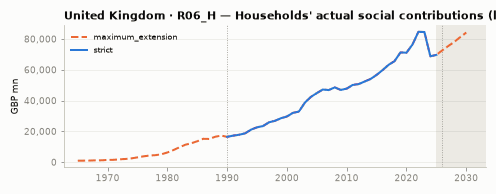

In [65]:
levels("GBR", "R06_H")

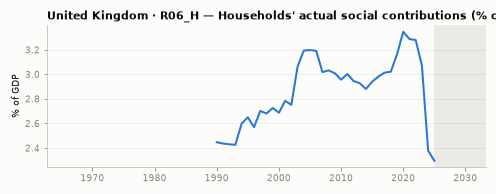

outturn 1990-2025; no official forecast


In [66]:
share("GBR", "R06_H")

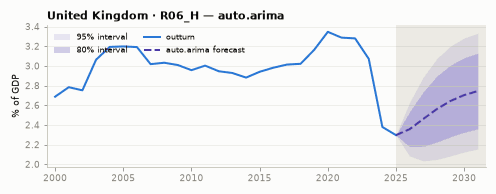

model: ARIMA(2, 0, 0)+drift; fitted on 1990-2025 (36 outturn observations). 2031: 2.74% of GDP, 95%
       interval 2.16 to 3.33.


In [67]:
fan("GBR", "R06_H", "auto.arima")

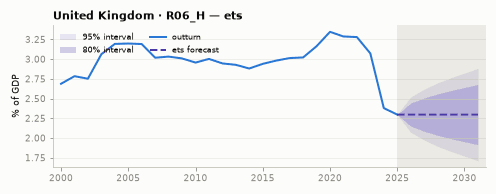

model: ETS(M,N,N); fitted on 1990-2025 (36 outturn observations). 2031: 2.30% of GDP, 95% interval 1.71
       to 2.88.


In [68]:
fan("GBR", "R06_H", "ets")

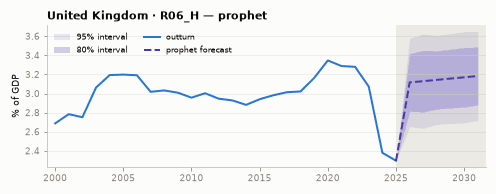

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: 3.18% of GDP, 95%
       interval 2.72 to 3.65.


In [69]:
fan("GBR", "R06_H", "prophet")

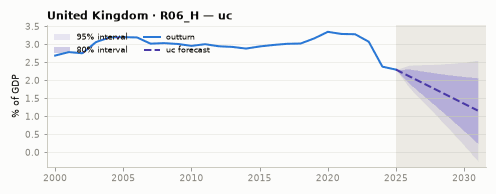

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031: 1.16%
       of GDP, 95% interval -0.23 to 2.55.


In [70]:
fan("GBR", "R06_H", "uc")

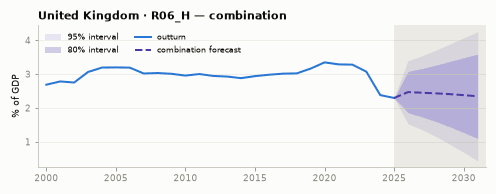

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: 2.35% of
       GDP, 95% interval 0.44 to 4.25.


In [71]:
fan("GBR", "R06_H", "combination")

## R06_X — Imputed and supplementary social contributions (D.612 + D.614 - D.61SC)

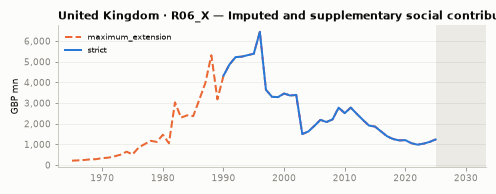

In [72]:
levels("GBR", "R06_X")

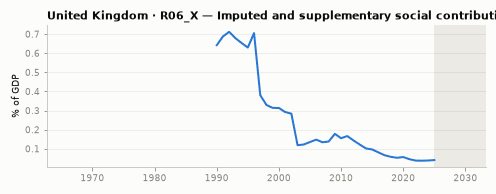

outturn 1990-2025; no official forecast


In [73]:
share("GBR", "R06_X")

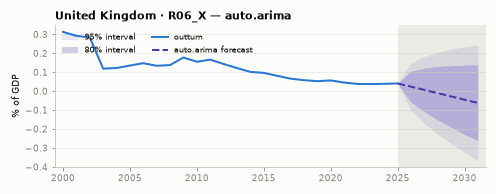

model: ARIMA(0, 1, 0)+drift; fitted on 1990-2025 (36 outturn observations). 2031: -0.06% of GDP, 95%
       interval -0.37 to 0.24.


In [74]:
fan("GBR", "R06_X", "auto.arima")

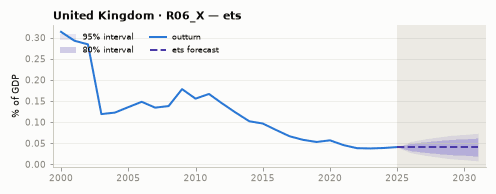

model: ETS(M,N,N); fitted on 1990-2025 (36 outturn observations). 2031: 0.04% of GDP, 95% interval 0.01
       to 0.07.


In [75]:
fan("GBR", "R06_X", "ets")

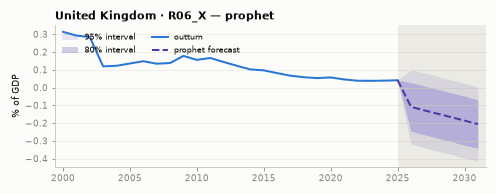

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: -0.21% of GDP, 95%
       interval -0.41 to 0.00.


In [76]:
fan("GBR", "R06_X", "prophet")

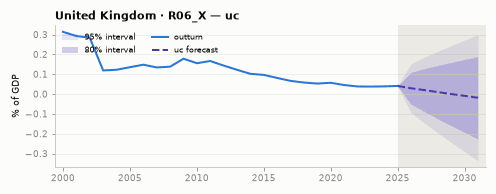

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031:
       -0.02% of GDP, 95% interval -0.34 to 0.30.


In [77]:
fan("GBR", "R06_X", "uc")

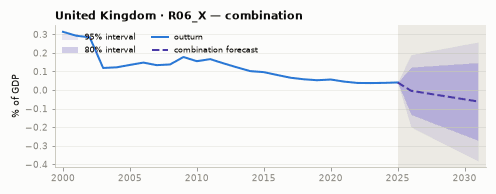

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: -0.06%
       of GDP, 95% interval -0.38 to 0.26.


In [78]:
fan("GBR", "R06_X", "combination")

## R07 — Interest receivable

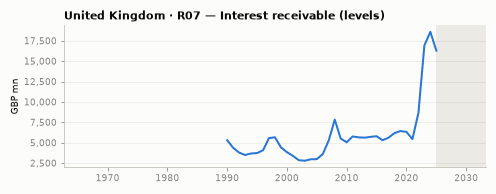

In [79]:
levels("GBR", "R07")

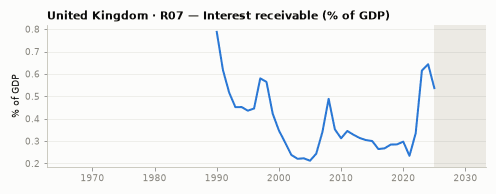

outturn 1990-2025; no official forecast


In [80]:
share("GBR", "R07")

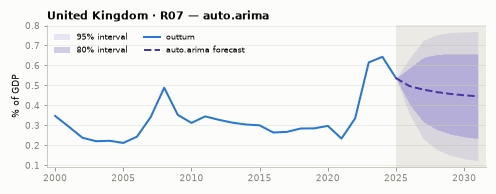

model: ARIMA(1, 0, 1)+drift; fitted on 1990-2025 (36 outturn observations). 2031: 0.45% of GDP, 95%
       interval 0.12 to 0.77.


In [81]:
fan("GBR", "R07", "auto.arima")

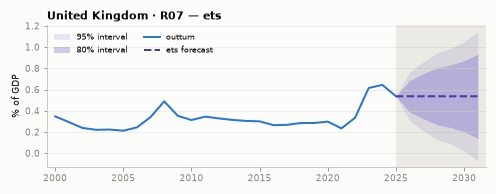

model: ETS(M,N,N); fitted on 1990-2025 (36 outturn observations). 2031: 0.54% of GDP, 95% interval -0.07
       to 1.14.


In [82]:
fan("GBR", "R07", "ets")

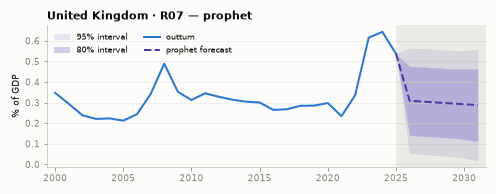

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: 0.29% of GDP, 95%
       interval 0.02 to 0.56.


In [83]:
fan("GBR", "R07", "prophet")

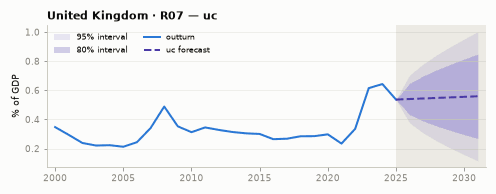

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031: 0.56%
       of GDP, 95% interval 0.12 to 1.00.


In [84]:
fan("GBR", "R07", "uc")

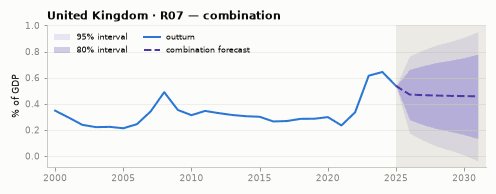

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: 0.46% of
       GDP, 95% interval -0.04 to 0.95.


In [85]:
fan("GBR", "R07", "combination")

## R08 — Other property income

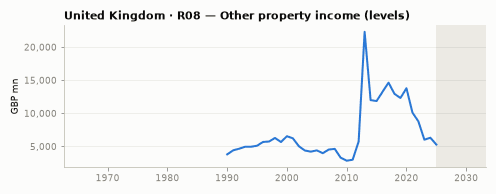

In [86]:
levels("GBR", "R08")

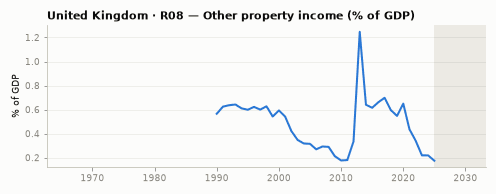

outturn 1990-2025; no official forecast


In [87]:
share("GBR", "R08")

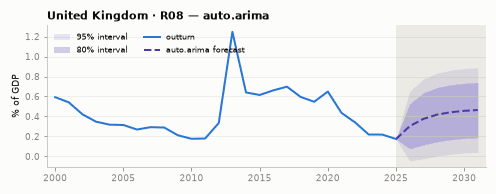

model: ARIMA(1, 0, 0)+drift; fitted on 1990-2025 (36 outturn observations). 2031: 0.46% of GDP, 95%
       interval 0.04 to 0.89.


In [88]:
fan("GBR", "R08", "auto.arima")

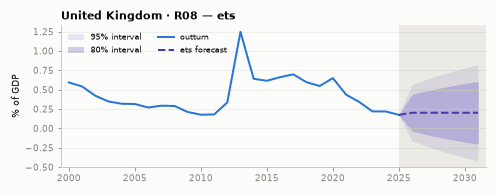

model: ETS(A,N,N); fitted on 1990-2025 (36 outturn observations). 2031: 0.20% of GDP, 95% interval -0.42
       to 0.82.


In [89]:
fan("GBR", "R08", "ets")

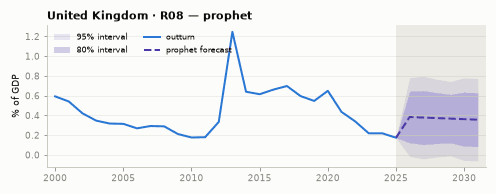

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: 0.36% of GDP, 95%
       interval -0.06 to 0.77.


In [90]:
fan("GBR", "R08", "prophet")

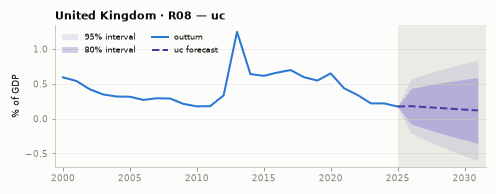

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031: 0.12%
       of GDP, 95% interval -0.60 to 0.84.


In [91]:
fan("GBR", "R08", "uc")

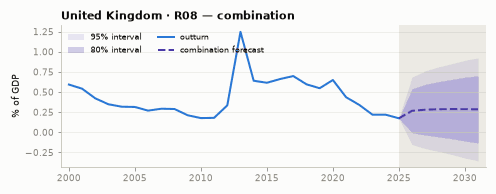

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: 0.29% of
       GDP, 95% interval -0.35 to 0.92.


In [92]:
fan("GBR", "R08", "combination")

## R09 — Sales of goods and services

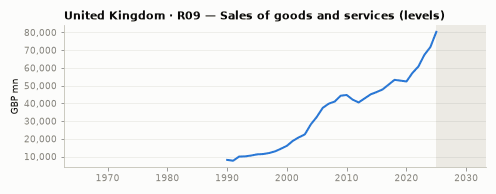

In [93]:
levels("GBR", "R09")

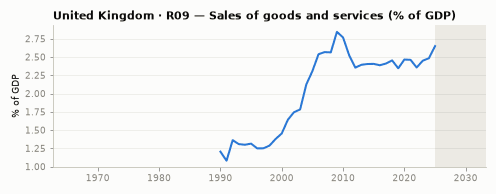

outturn 1990-2025; no official forecast


In [94]:
share("GBR", "R09")

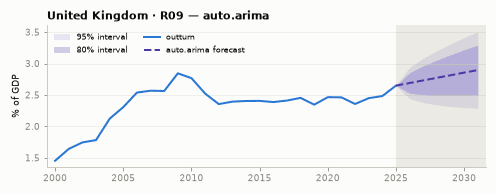

model: ARIMA(0, 1, 0)+drift; fitted on 1990-2025 (36 outturn observations). 2031: 2.90% of GDP, 95%
       interval 2.29 to 3.50.


In [95]:
fan("GBR", "R09", "auto.arima")

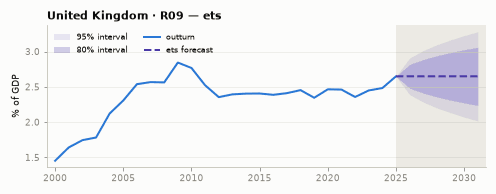

model: ETS(A,N,N); fitted on 1990-2025 (36 outturn observations). 2031: 2.65% of GDP, 95% interval 2.02
       to 3.28.


In [96]:
fan("GBR", "R09", "ets")

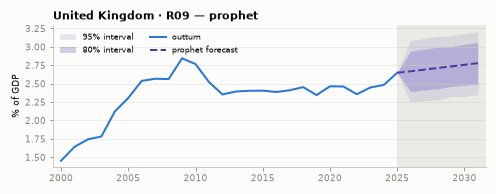

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: 2.78% of GDP, 95%
       interval 2.35 to 3.20.


In [97]:
fan("GBR", "R09", "prophet")

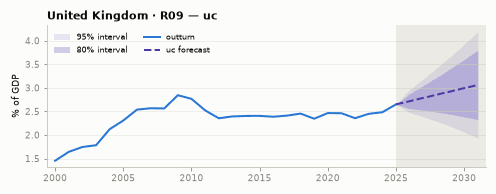

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031: 3.06%
       of GDP, 95% interval 1.94 to 4.19.


In [98]:
fan("GBR", "R09", "uc")

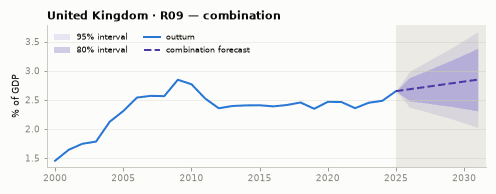

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: 2.85% of
       GDP, 95% interval 2.03 to 3.67.


In [99]:
fan("GBR", "R09", "combination")

## R10 — Other current and capital transfers receivable

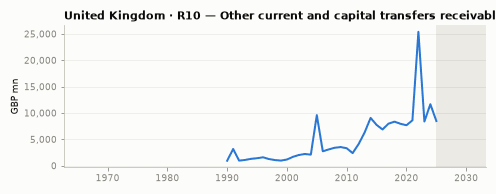

In [100]:
levels("GBR", "R10")

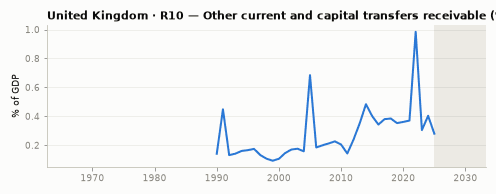

outturn 1990-2025; no official forecast


In [101]:
share("GBR", "R10")

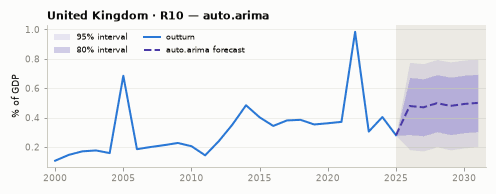

model: ARIMA(3, 1, 1)+drift; fitted on 1990-2025 (36 outturn observations). 2031: 0.50% of GDP, 95%
       interval 0.20 to 0.80.


In [102]:
fan("GBR", "R10", "auto.arima")

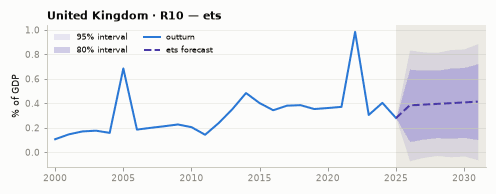

model: ETS(M,A,N); fitted on 1990-2025 (36 outturn observations). 2031: 0.41% of GDP, 95% interval -0.06
       to 0.89.


In [103]:
fan("GBR", "R10", "ets")

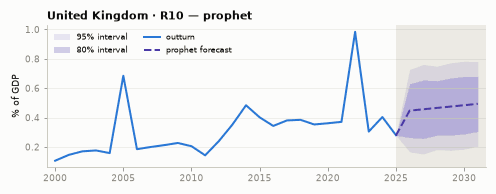

model: Prophet(linear trend); fitted on 1990-2025 (36 outturn observations). 2031: 0.49% of GDP, 95%
       interval 0.21 to 0.78.


In [104]:
fan("GBR", "R10", "prophet")

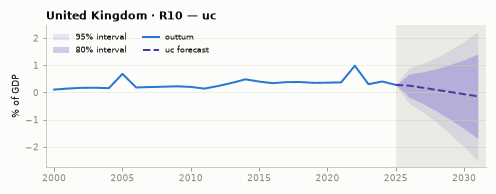

model: UC(local linear trend + damped cycle); fitted on 1990-2025 (36 outturn observations). 2031:
       -0.14% of GDP, 95% interval -2.51 to 2.23.


In [105]:
fan("GBR", "R10", "uc")

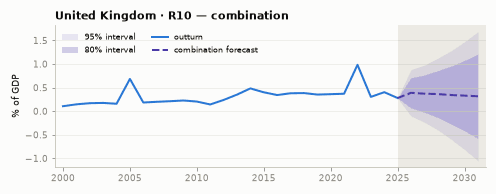

model: mean of 4 + between-model variance; fitted on 1990-2025 (36 outturn observations). 2031: 0.32% of
       GDP, 95% interval -1.05 to 1.68.


In [106]:
fan("GBR", "R10", "combination")